# Titanic Survival Prediction

I pulled this into a focused project so it feels more like a real repo and less like a class notebook. The goal is to predict passenger survival and compare a linear baseline against a tree-based model.

## Game Plan

- load and inspect the data
- build a clean train/test split
- use one preprocessing pipeline for both models
- tune Logistic Regression and Random Forest
- compare F1, ROC-AUC, and confusion matrices

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
IMAGES_DIR = PROJECT_ROOT / 'images'
RESULTS_DIR = PROJECT_ROOT / 'results'
for folder in [DATA_DIR, IMAGES_DIR, RESULTS_DIR]:
    folder.mkdir(exist_ok=True)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')

In [2]:
titanic = pd.read_csv(DATA_DIR / 'titanic.csv')
print(f'Shape: {titanic.shape}')
titanic.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


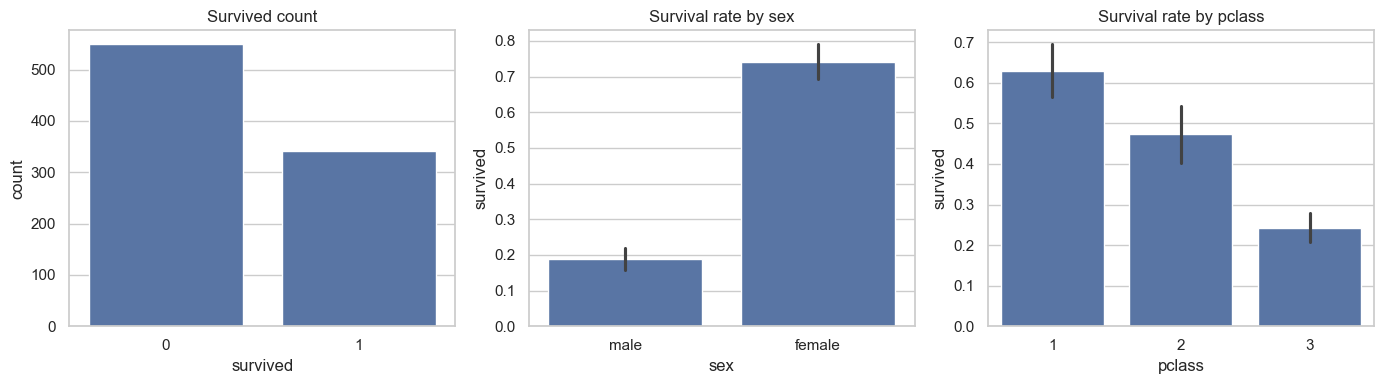

In [3]:
working_df = titanic[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']].copy()
working_df['family_size'] = working_df['sibsp'] + working_df['parch'] + 1
working_df['is_alone'] = (working_df['family_size'] == 1).astype(int)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
sns.countplot(data=working_df, x='survived', ax=ax[0])
ax[0].set_title('Survived count')
sns.barplot(data=working_df, x='sex', y='survived', ax=ax[1])
ax[1].set_title('Survival rate by sex')
sns.barplot(data=working_df, x='pclass', y='survived', ax=ax[2])
ax[2].set_title('Survival rate by pclass')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'survival_overview.png', dpi=200, bbox_inches='tight')
plt.show()

In [4]:
X = working_df.drop(columns='survived')
y = working_df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
print('Numeric columns:', num_cols)
print('Categorical columns:', cat_cols)

Numeric columns: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone']
Categorical columns: ['sex', 'embarked']


C:\Users\albec\AppData\Local\Temp\ipykernel_10800\2824492843.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


In [5]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [6]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE)),
])
rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10],
    'classifier__min_samples_split': [2, 5],
}
rf_model = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=1,
)
rf_model.fit(X_train, y_train)
print('RF best params:', rf_model.best_params_)
print('RF best CV F1:', round(rf_model.best_score_, 4))

RF best params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
RF best CV F1: 0.7508


In [7]:
log_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1500)),
])
log_param_grid = {
    'classifier__C': [0.1, 1, 10],
}
log_model = GridSearchCV(
    estimator=log_pipeline,
    param_grid=log_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=1,
)
log_model.fit(X_train, y_train)
print('Logistic best params:', log_model.best_params_)
print('Logistic best CV F1:', round(log_model.best_score_, 4))

Logistic best params: {'classifier__C': 1}
Logistic best CV F1: 0.7294


In [8]:
def evaluate_model(name, fitted_model):
    y_pred = fitted_model.predict(X_test)
    y_prob = fitted_model.predict_proba(X_test)[:, 1]
    print(f'\n{name} classification report:')
    print(classification_report(y_test, y_pred))
    return {
        'Model': name,
        'Best CV F1': fitted_model.best_score_,
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test F1': f1_score(y_test, y_pred),
        'Test ROC-AUC': roc_auc_score(y_test, y_prob),
        'y_pred': y_pred,
    }

log_results = evaluate_model('Logistic Regression', log_model)
rf_results = evaluate_model('Random Forest', rf_model)
comparison_df = pd.DataFrame([
    {k: v for k, v in log_results.items() if k != 'y_pred'},
    {k: v for k, v in rf_results.items() if k != 'y_pred'},
]).sort_values(by='Test F1', ascending=False)
comparison_df.round(4)


Logistic Regression classification report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


Random Forest classification report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



,Model,Best CV F1,Test Accuracy,Test F1,Test ROC-AUC
0,Logistic Regression,0.7294,0.8045,0.7287,0.8505
1,Random Forest,0.7508,0.8045,0.7244,0.8327


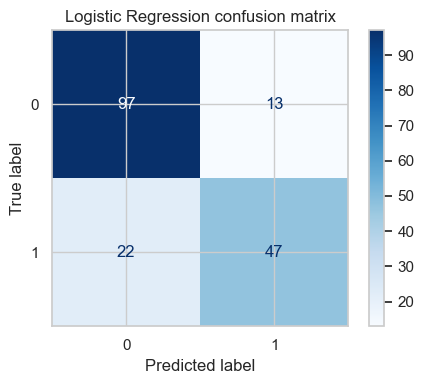

In [9]:
best_row = comparison_df.iloc[0]
best_name = best_row['Model']
best_pred = log_results['y_pred'] if best_name == 'Logistic Regression' else rf_results['y_pred']
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, cmap='Blues', ax=ax)
ax.set_title(f'{best_name} confusion matrix')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'best_model_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

C:\Users\albec\AppData\Local\Temp\ipykernel_10800\2001490990.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_feature_importance, x='importance', y='feature', palette='Blues_r')


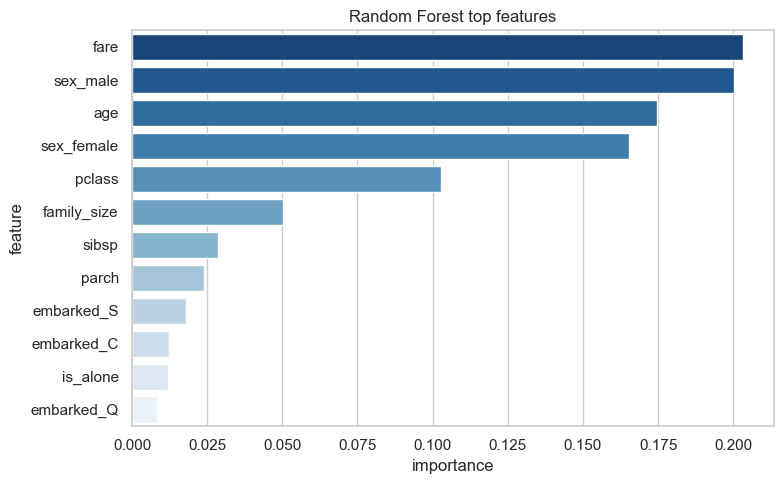

,feature,importance
4,fare,0.203391
8,sex_male,0.200323
1,age,0.174619
7,sex_female,0.165195
0,pclass,0.102623
5,family_size,0.050386
2,sibsp,0.028762
3,parch,0.024004
11,embarked_S,0.018048
9,embarked_C,0.012279


In [10]:
rf_feature_names = num_cols + list(
    rf_model.best_estimator_['preprocessor']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(cat_cols)
)
rf_feature_importance = pd.DataFrame({
    'feature': rf_feature_names,
    'importance': rf_model.best_estimator_['classifier'].feature_importances_,
}).sort_values(by='importance', ascending=False).head(12)

plt.figure(figsize=(8, 5))
sns.barplot(data=rf_feature_importance, x='importance', y='feature', palette='Blues_r')
plt.title('Random Forest top features')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'random_forest_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()
rf_feature_importance

In [11]:
summary = {
    'dataset_rows': int(working_df.shape[0]),
    'dataset_columns': int(working_df.shape[1]),
    'best_model': best_name,
    'comparison': comparison_df.round(4).to_dict(orient='records'),
    'best_params': {
        'logistic_regression': log_model.best_params_,
        'random_forest': rf_model.best_params_,
    },
}
with open(RESULTS_DIR / 'metrics.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)
comparison_df.round(4).to_csv(RESULTS_DIR / 'comparison.csv', index=False)
summary

{'dataset_rows': 891,
 'dataset_columns': 10,
 'best_model': 'Logistic Regression',
 'comparison': [{'Model': 'Logistic Regression',
   'Best CV F1': 0.7294,
   'Test Accuracy': 0.8045,
   'Test F1': 0.7287,
   'Test ROC-AUC': 0.8505},
  {'Model': 'Random Forest',
   'Best CV F1': 0.7508,
   'Test Accuracy': 0.8045,
   'Test F1': 0.7244,
   'Test ROC-AUC': 0.8327}],
 'best_params': {'logistic_regression': {'classifier__C': 1},
  'random_forest': {'classifier__max_depth': 10,
   'classifier__min_samples_split': 5,
   'classifier__n_estimators': 100}}}